# MNIST classification
Yasir Ahmad
22MIA1064

## Load MNIST Dataset

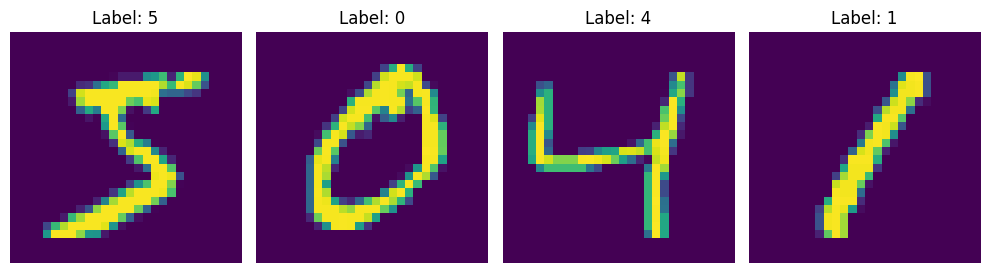

In [30]:
from tensorflow.keras.datasets import mnist #type: ignore
import tensorflow as tf 
from tensorflow import keras 
import matplotlib.pyplot as plt
import numpy as np

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Print 4 images in a row
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(X_train[i])
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


## Preprocessing

In [11]:
# Normalizing the dataset 
X_train = X_train/255
X_test = X_test/255

# Flatting the dataset in order 
# to compute for model building 
X_train_flatten = X_train.reshape(len(X_train), 28*28) 
X_test_flatten = X_test.reshape(len(X_test), 28*28) 


In [12]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

## Model

In [43]:
metrics = {"Model 1":[],"Model 2":[],"Model 3":[]}

### Model 1 (Single layer Perceptron)

In [44]:

model = keras.Sequential([ 
	keras.layers.Dense(10, input_shape=(784,), activation='softmax') 
]) 
model.compile( 
	optimizer='adam', 
	loss='sparse_categorical_crossentropy', 
	metrics=['accuracy']) 

model.fit(X_train_flatten, y_train, epochs=5) 


Epoch 1/5
1875/1875 [==============================] - 14s 6ms/step - loss: 0.4728 - accuracy: 0.8761
Epoch 2/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3042 - accuracy: 0.9159
Epoch 3/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.2837 - accuracy: 0.9202
Epoch 4/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.2731 - accuracy: 0.9239
Epoch 5/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.2667 - accuracy: 0.9251


#### Model Architecture

In [45]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 10)                7850      
                                                                 
Total params: 7850 (30.66 KB)
Trainable params: 7850 (30.66 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


#### Evalutation

In [46]:
metrics["Model 1"] = model.evaluate(X_test_flatten, y_test) 


313/313 [==============================] - 2s 5ms/step - loss: 0.2657 - accuracy: 0.9253


In [47]:
y_pred = model.predict(X_test_flatten)


313/313 [==============================] - 2s 4ms/step


In [48]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

#### Visualization

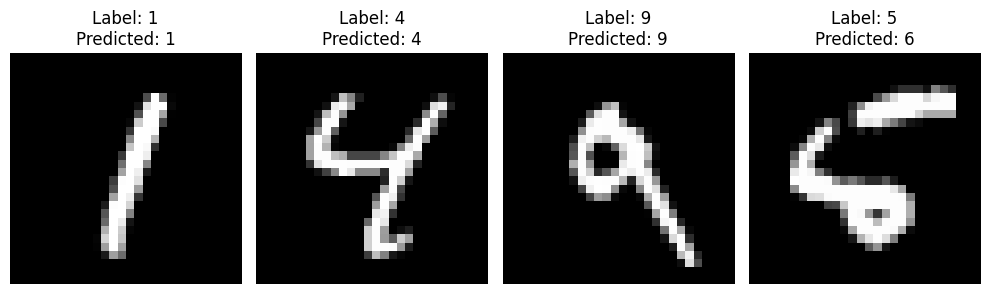

In [49]:
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(X_test[i+5], cmap= 'gray')
    
    plt.title(f"Label: {y_test[i+5]}\nPredicted: {np.argmax(y_pred[i+5])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Model 2 (Multilayer Perceptron)

In [50]:

model = keras.Sequential([ 
	keras.layers.Dense(5, input_shape=(784,), activation='sigmoid'),
    keras.layers.Dense(10, input_shape=(784,), activation='softmax')
     
]) 
model.compile( 
	optimizer='adam', 
	loss='sparse_categorical_crossentropy', 
	metrics=['accuracy']) 

model.fit(X_train_flatten, y_train, epochs=10) 


Epoch 1/10
1875/1875 [==============================] - 13s 6ms/step - loss: 1.4295 - accuracy: 0.6636
Epoch 2/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.8414 - accuracy: 0.7873
Epoch 3/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.6797 - accuracy: 0.8151
Epoch 4/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.5997 - accuracy: 0.8347
Epoch 5/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.5516 - accuracy: 0.8451
Epoch 6/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.5208 - accuracy: 0.8517
Epoch 7/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.4994 - accuracy: 0.8566
Epoch 8/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.4848 - accuracy: 0.8595
Epoch 9/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.4738 - accuracy: 0.8625
Epoch 10/10
1875/1875 [==============================] - 9s 5ms/step - loss

#### Model Architecture

In [51]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 5)                 3925      
                                                                 
 dense_11 (Dense)            (None, 10)                60        
                                                                 
Total params: 3985 (15.57 KB)
Trainable params: 3985 (15.57 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


#### Evalutation

In [52]:
metrics["Model 2"]=model.evaluate(X_test_flatten, y_test)

313/313 [==============================] - 5s 8ms/step - loss: 0.4763 - accuracy: 0.8622


In [53]:
y_pred = model.predict(X_test_flatten)

313/313 [==============================] - 3s 7ms/step


#### Visualization

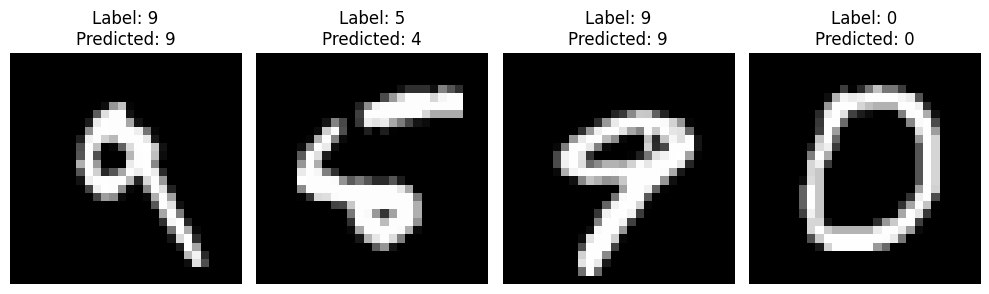

In [54]:
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(X_test[i+7], cmap= 'gray')
    
    plt.title(f"Label: {y_test[i+7]}\nPredicted: {np.argmax(y_pred[i+7])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Model 3 (CNN)

In [56]:

model = keras.Sequential([
	keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
	keras.layers.MaxPooling2D(pool_size=(2, 2)),
	keras.layers.Flatten(),
	keras.layers.Dense(128, activation='relu'),
	keras.layers.Dense(10, activation='softmax')
])

model.compile(
	optimizer='adam',
	loss='sparse_categorical_crossentropy',
	metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=3)


Epoch 1/3
1875/1875 [==============================] - 41s 20ms/step - loss: 0.7094 - accuracy: 0.9319
Epoch 2/3
1875/1875 [==============================] - 33s 18ms/step - loss: 0.0822 - accuracy: 0.9767
Epoch 3/3
1875/1875 [==============================] - 34s 18ms/step - loss: 0.0600 - accuracy: 0.9815


#### Model Architecture

In [57]:
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 13, 13, 32)        0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 5408)              0         
                                                                 
 dense_14 (Dense)            (None, 128)               692352    
                                                                 
 dense_15 (Dense)            (None, 10)                1290      
                                                                 
Total params: 693962 (2.65 MB)
Trainable params: 693962 (2.65 MB)
Non-trainable params: 0 (0.00 Byte)
__________________

#### Evaluation

In [58]:
metrics["Model 3"]=model.evaluate(X_test, y_test)

313/313 [==============================] - 4s 10ms/step - loss: 0.0833 - accuracy: 0.9768


In [59]:
y_pred = model.predict(X_test)

313/313 [==============================] - 2s 7ms/step


#### Visualization

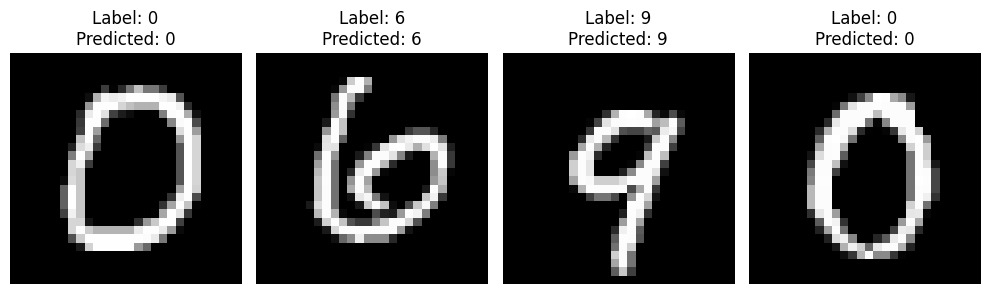

In [60]:
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(X_test[i+10], cmap= 'gray')
    
    plt.title(f"Label: {y_test[i+10]}\nPredicted: {np.argmax(y_pred[i+10])}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Summary

In [64]:
summary = {}

for model, values in metrics.items():
    loss, accuracy = values
    summary[model] = {
        'Loss': loss,
        'Accuracy': accuracy
    }

for model, values in summary.items():
    print(f"{model}: Loss = {values['Loss']}, Accuracy = {values['Accuracy']}")

Model 1: Loss = 0.2656765878200531, Accuracy = 0.9253000020980835
Model 2: Loss = 0.476335346698761, Accuracy = 0.8622000217437744
Model 3: Loss = 0.08334559202194214, Accuracy = 0.9768000245094299


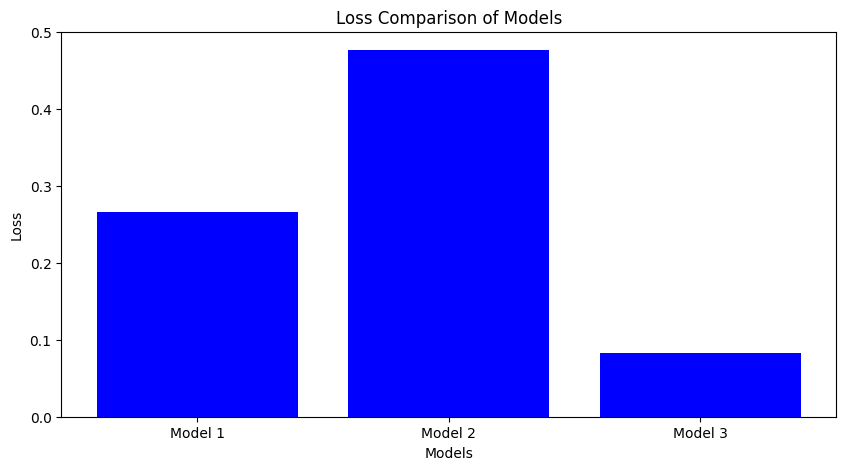

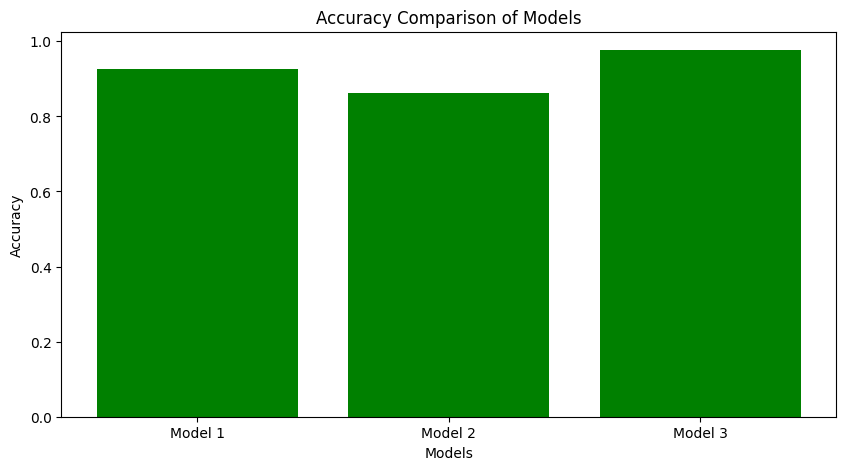

In [65]:
import matplotlib.pyplot as plt

models = list(metrics.keys())
losses = [metrics[model][0] for model in models]
accuracies = [metrics[model][1] for model in models]

# Plot for Loss Comparison
plt.figure(figsize=(10, 5))
plt.bar(models, losses, color='blue')
plt.xlabel('Models')
plt.ylabel('Loss')
plt.title('Loss Comparison of Models')
plt.show()

# Plot for Accuracy Comparison
plt.figure(figsize=(10, 5))
plt.bar(models, accuracies, color='green')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Models')
plt.show()